In [1]:
import pandas as pd

df = pd.read_csv(r"datasets/meta_data/audio_meta_data.csv")
df.head()


,episode_id,trancription_id,num_speakers,transcript_available,category,duration_seconds,source
0,audio1.mp3,audio1.txt,1,yes,podcast,3397.88,hacker public radio
1,audio2.mp3,audio2.txt,1,yes,podcast,2415.60,hacker public radio
2,audio3.mp3,audio3.txt,1,yes,podcast,1705.20,hacker public radio
3,audio4.mp3,audio4.txt,1,yes,podcast,1096.20,hacker public radio
4,audio5.mp3,audio5.txt,2,yes,podcast,1888.80,hacker public radio


In [2]:
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
audio_folder = "datasets/raw_audio"
transcript_folder = "datasets/transcripts"
metadata_folder = "datasets/meta_data"



In [4]:
audio_data = []

for file in os.listdir(audio_folder):
    if file.lower().endswith((".wav", ".mp3")):
        path = os.path.join(audio_folder, file)

        duration = librosa.get_duration(path=path)
        sr = librosa.get_samplerate(path)
        size = os.path.getsize(path) / (1024 * 1024)  # MB

        # load short sample for noise analysis
        y, _ = librosa.load(path, duration=5)

        noise_level = np.mean(np.abs(y))   # simple noise indicator

        audio_data.append([file, duration, sr, size, noise_level])

audio_df = pd.DataFrame(audio_data, columns=[
    "file", "duration_sec", "sample_rate", "size_MB", "noise_level"
])

audio_df.head()


C:\Users\ASHOKA MS\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,file,duration_sec,sample_rate,size_MB,noise_level
0,audio13.mp3,3707.508979,48000,42.504301,0.044135


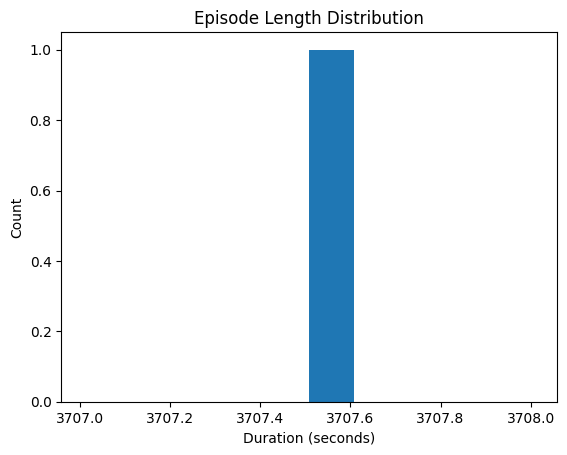

In [5]:
plt.hist(audio_df["duration_sec"], bins=10)
plt.title("Episode Length Distribution")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.show()


In [7]:

print("Sampling Rate Counts:")
print(audio_df["sample_rate"].value_counts())


Sampling Rate Counts:
sample_rate
48000    1
Name: count, dtype: int64


In [8]:
print(" File Size (MB):", round(audio_df["size_MB"].mean(), 2))


 File Size (MB): 42.5


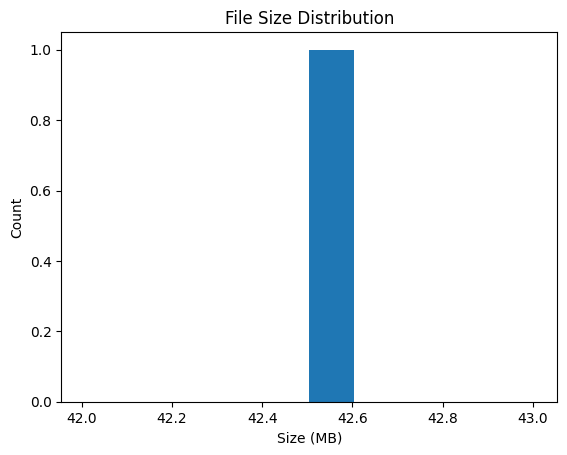

In [9]:
plt.hist(audio_df["size_MB"], bins=10)
plt.title("File Size Distribution")
plt.xlabel("Size (MB)")
plt.ylabel("Count")
plt.show()


In [10]:
print(" Noise Level:", round(audio_df["noise_level"].mean(), 5))


 Noise Level: 0.04414


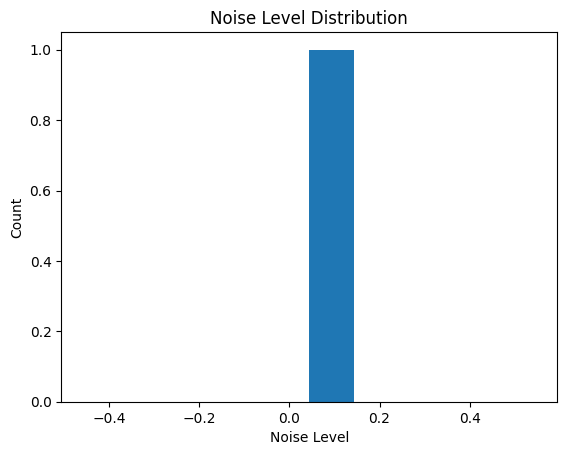

In [11]:
plt.hist(audio_df["noise_level"], bins=10)
plt.title("Noise Level Distribution")
plt.xlabel("Noise Level")
plt.ylabel("Count")
plt.show()


In [13]:
print("Noise Level Variation:", round(audio_df["noise_level"].std(), 5))


Noise Level Variation: nan


In [14]:
with open(os.path.join(transcript_folder, trans_df["file"][0]), encoding="utf-8") as f:
    print(f.read()[:500])


NameError: name 'trans_df' is not defined

In [15]:
transcript_data = []

for file in os.listdir(transcript_folder):
    if file.endswith(".txt"):
        path = os.path.join(transcript_folder, file)

        with open(path, "r", encoding="utf-8") as f:
            text = f.read()

        word_count = len(text.split())
        char_count = len(text)
        line_count = text.count("\n") + 1

        transcript_data.append([file, word_count, char_count, line_count])

trans_df = pd.DataFrame(transcript_data, columns=[
    "file", "word_count", "char_count", "line_count"
])

trans_df.head()


,file,word_count,char_count,line_count
0,audio13.txt,9563,52032,589


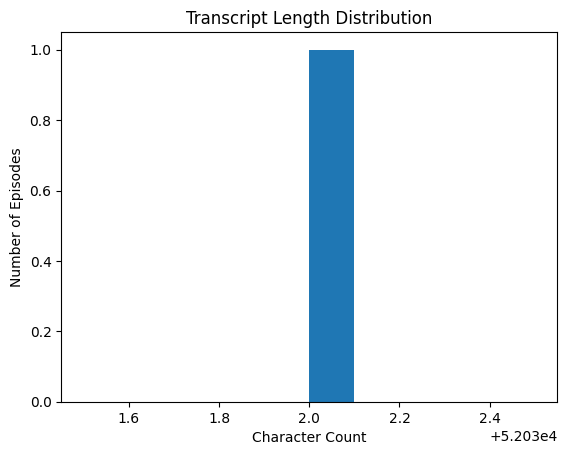

In [16]:
plt.hist(trans_df["char_count"], bins=10)
plt.title("Transcript Length Distribution")
plt.xlabel("Character Count")
plt.ylabel("Number of Episodes")
plt.show()


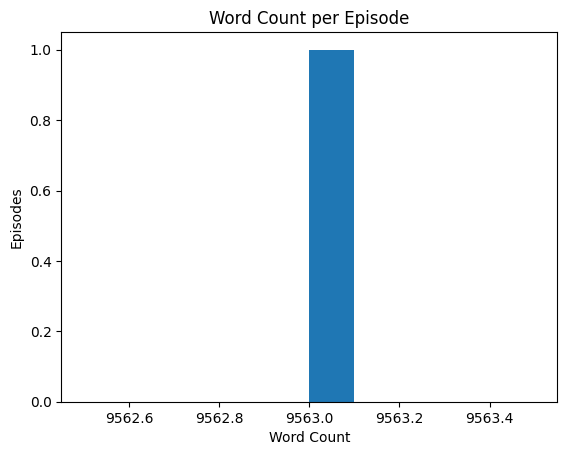

In [17]:
plt.hist(trans_df["word_count"], bins=10)
plt.title("Word Count per Episode")
plt.xlabel("Word Count")
plt.ylabel("Episodes")
plt.show()


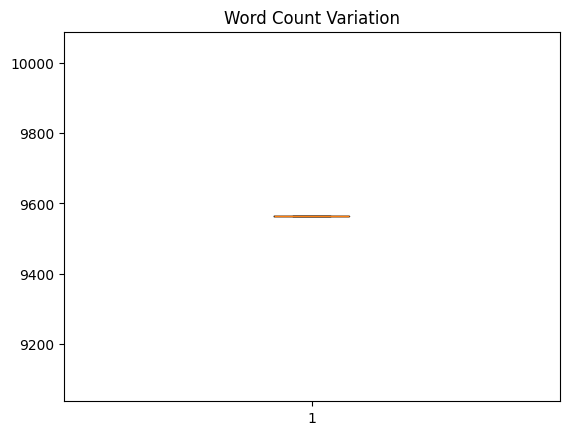

In [18]:
plt.boxplot(trans_df["word_count"])
plt.title("Word Count Variation")
plt.show()

In [19]:
print("words per transcript:",
      round(trans_df["word_count"].mean(), 2))


words per transcript: 9563.0


In [20]:
with open(os.path.join(transcript_folder, trans_df["file"][0]), encoding="utf-8") as f:
    print(f.read()[:500])


when it comes to the question of economy which is going to benefit everybody the
politics cannot be so disrupt Once Upon a Time prime minister Rajiv Gandhi said
if I send one rupee to the beneficiary he ends up getting only 15 P adopting
technology Prime Ministers ensured that that kind of leakage doesn't happen one
rup sent is one Rupee received one of the most crucial Ministries in Mod's cabinet the Ministry of Finance has been
ENT trusted to Nala sitaraman she's one of the top ministers in th


In [21]:
timestamp_count = 0

for file in os.listdir(transcript_folder):
    if file.endswith(".txt"):
        with open(os.path.join(transcript_folder, file), encoding="utf-8") as f:
            text = f.read()

        if ":" in text or "[" in text:
            timestamp_count += 1

print("Transcripts with timestamps:", timestamp_count)


Transcripts with timestamps: 1


In [22]:
timestamp_percent = (timestamp_count / len(trans_df)) * 100
print("Timestamp presence:", round(timestamp_percent, 2), "%")


Timestamp presence: 100.0 %


In [23]:
audio_count = len(os.listdir("datasets/raw_audio"))
transcript_count = len(trans_df)

missing_percent = ((audio_count - transcript_count) / audio_count) * 100

print("Missing Transcript %:", round(missing_percent, 2))


Missing Transcript %: 0.0
